# Leiden

| | G_internal | G_combined |
|---|---|---|
| **Type** | Undirected, unweighted | Undirected, weighted (BC score) |
| **Edges** | Citation links only | Citations + bibliographic coupling |
| **CD input** | `graph_internal_2020.gpickle` | `graph_combined_2020.gpickle` |
| **Leiden variant** | `ModularityVertexPartition` | `ModularityVertexPartition` (w/ weights) |

In [1]:
import os, re, time, pickle, textwrap, warnings
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import igraph as ig
import leidenalg
from sklearn.metrics import normalized_mutual_info_score, mutual_info_score
from scipy.stats import entropy as scipy_entropy

from cdlib import NodeClustering, evaluation

GRAPH_DIR     = "../00_graph_construction/output/graphs"
INTERNAL_PATH = os.path.join(GRAPH_DIR, "graph_internal_2020.gpickle")
COMBINED_PATH = os.path.join(GRAPH_DIR, "graph_combined_2020.gpickle")

N_RUN         = 100
TOP_N_COMMS   = 20
TOP_K         = 5
MIN_COMM_SIZE = 50

In [2]:
def load_graph(filepath: str):
    with open(filepath, 'rb') as fh:
        return pickle.load(fh)

G_internal       = load_graph(INTERNAL_PATH)
G_combined       = load_graph(COMBINED_PATH)
G_internal_undir = G_internal.to_undirected()

w = [d['weight'] for _, _, d in G_combined.edges(data=True) if 'weight' in d]

print(f"G_internal  {G_internal.number_of_nodes():>7,} nodes  {G_internal.number_of_edges():>8,} edges  (directed, unweighted)")
print(f"G_combined  {G_combined.number_of_nodes():>7,} nodes  {G_combined.number_of_edges():>8,} edges  "
      f"| weights: median={np.median(w):.3f}  range=[{min(w):.3f}, {max(w):.3f}]")

G_internal   55,078 nodes   217,925 edges  (directed, unweighted)
G_combined   58,627 nodes   590,157 edges  | weights: median=0.249  range=[0.095, 1.000]


In [3]:
def _split_labels(raw_value):
    return [p.strip() for p in re.split(r';\s*', str(raw_value)) if p.strip()]

def _extract_l2(counter):
    l2 = Counter()
    for label, count in counter.items():
        if re.match(r'^\d{2}', label):
            l2[label[:2]] += count
    return l2

def compute_attr_stats(G, attributes=('FOS', 'SDG')):
    """Count labels per attribute; add 2-digit aggregation for FOS."""
    stats = {}
    for attr in attributes:
        counts = Counter()
        n_nodes = 0
        for _, data in G.nodes(data=True):
            val = data.get(attr)
            if not val:
                continue
            n_nodes += 1
            counts.update(_split_labels(val))
        stats[attr] = {'counts': counts, 'n_nodes': n_nodes}
        if attr == 'FOS':
            stats['FOS_L2'] = {'counts': _extract_l2(counts), 'n_nodes': n_nodes}
    return stats

def compare_attr_stats(stats_int, stats_comb, key):
    n_i = stats_int[key]['n_nodes']
    n_c = stats_comb[key]['n_nodes']
    all_labels = sorted(set(stats_int[key]['counts']) | set(stats_comb[key]['counts']))

    rows = []
    for label in all_labels:
        ci = stats_int[key]['counts'].get(label, 0)
        cc = stats_comb[key]['counts'].get(label, 0)
        rows.append({
            'label': label,
            'int_cnt': ci,  'int_pct': ci / n_i * 100 if n_i else 0,
            'comb_cnt': cc, 'comb_pct': cc / n_c * 100 if n_c else 0,
        })
    return pd.DataFrame(rows)

In [4]:
s_int  = compute_attr_stats(G_internal)
s_comb = compute_attr_stats(G_combined)

pd.concat([
    compare_attr_stats(s_int, s_comb, 'FOS').assign(level='detail'),
    compare_attr_stats(s_int, s_comb, 'FOS_L2').assign(level='L2'),
], ignore_index=True).to_csv('FOS_stats.csv', index=False)

compare_attr_stats(s_int, s_comb, 'SDG') \
    .sort_values('int_cnt', ascending=False) \
    .to_csv('SDG_stats.csv', index=False)

print('FOS_stats.csv  SDG_stats.csv  created')

FOS_stats.csv  SDG_stats.csv  created


## Leiden - Modularity optimisation

Leiden (Traag et al., 2019) improves Louvain by enforcing internally connected communities.

- Objective: maximize Newman-Girvan modularity
- Variant: `ModularityVertexPartition`
- `G_internal`: unweighted
- `G_combined`: weighted on `weight`

### Ensemble and medoid selection

To improve robustness on degenerate solutions:

1. Run Leiden 100 times (seeds 1..100)
2. Compute pairwise NMI (100x100 matrix)
3. Select the medoid run (highest average NMI)

The medoid is used as representative partition for downstream analysis.

In [5]:
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

def compute_nmi_matrix(labels_list, n_workers=10):
    """Pairwise NMI between all runs (parallelized)."""
    n = len(labels_list)
    mat = np.eye(n)
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]

    def _nmi(pair):
        i, j = pair
        return i, j, normalized_mutual_info_score(
            labels_list[i], labels_list[j], average_method='arithmetic'
        )

    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        for i, j, v in pool.map(_nmi, pairs):
            mat[i, j] = mat[j, i] = v
    return mat


def _run_single_leiden(args):
    """Worker: run one Leiden partition. Returns seed, labels, communities."""
    seed, g_ig_pickled, n_nodes, weights = args
    import pickle, leidenalg
    import numpy as np

    G_ig = pickle.loads(g_ig_pickled)
    partition = leidenalg.find_partition(
        G_ig, leidenalg.ModularityVertexPartition,
        weights=weights, seed=seed
    )

    labels = np.full(n_nodes, -1, dtype=np.int32)
    communities = []
    for cid, comm in enumerate(partition):
        communities.append(list(comm))  # igraph indices
        for idx in comm:
            labels[idx] = cid

    return seed, labels, communities


def select_medoid(nmi_matrix):
    """Return (medoid_index, per-run_avg_nmi, upper-triangle_values)."""
    n = nmi_matrix.shape[0]
    avg_nmi = (nmi_matrix.sum(axis=1) - 1.0) / (n - 1)
    return int(np.argmax(avg_nmi)), avg_nmi, nmi_matrix[np.triu_indices(n, k=1)]


def run_leiden_ensemble(G_nx, graph_name, weights=None,
                        n_runs=100, base_seed=1, n_workers=12):
    """Run Leiden n_runs times in parallel, return medoid partition + stats."""
    t0 = time.time()
    nodes_list = list(G_nx.nodes())
    node_to_idx = {n: i for i, n in enumerate(nodes_list)}
    G_ig = ig.Graph.from_networkx(G_nx)

    print(f"--- Leiden ensemble: {graph_name} ---")
    print(f"    Runs: {n_runs} | Weights: {weights or 'None'} | Workers: {n_workers}")

    # --- Run ensemble in parallel ---
    g_ig_pickled = pickle.dumps(G_ig)
    args = [(seed, g_ig_pickled, len(nodes_list), weights)
            for seed in range(base_seed, base_seed + n_runs)]

    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        raw_results = list(pool.map(_run_single_leiden, args))

    print(f"    Leiden runs: {time.time() - t0:.1f}s")

    # --- Reconstruct NodeClustering objects in main process ---
    results = []
    for seed, labels, ig_communities in raw_results:
        communities = [[nodes_list[i] for i in comm] for comm in ig_communities]
        results.append({
            'seed': seed, 'labels': labels,
            'clustering': NodeClustering(communities, graph=G_nx, method_name='leiden'),
            'n_communities': len(communities)
        })

    # --- Select medoid ---
    t_nmi = time.time()
    nmi_matrix = compute_nmi_matrix([r['labels'] for r in results])
    print(f"    NMI matrix: {time.time() - t_nmi:.1f}s")

    medoid_idx, avg_nmi, nmi_vals = select_medoid(nmi_matrix)
    medoid = results[medoid_idx]
    medoid_mod = evaluation.newman_girvan_modularity(G_nx, medoid['clustering']).score

    print(f"  NMI  min/mean/max/std : {nmi_vals.min():.4f} / {nmi_vals.mean():.4f} / {nmi_vals.max():.4f} / {nmi_vals.std():.4f}")
    print(f"  Medoid seed           : {medoid['seed']}  (idx {medoid_idx})")
    print(f"  Medoid avg NMI        : {avg_nmi[medoid_idx]:.4f}  |  #comms: {medoid['n_communities']}")
    print(f"  Modularity            : {medoid_mod:.4f}  |  Elapsed: {time.time() - t0:.1f}s\n")

    stats = {
        'graph_name': graph_name, 'n_runs': n_runs,
        'nmi_min': float(nmi_vals.min()), 'nmi_max': float(nmi_vals.max()),
        'nmi_mean': float(nmi_vals.mean()), 'nmi_std': float(nmi_vals.std()),
        'medoid_idx': medoid_idx, 'medoid_seed': medoid['seed'],
        'medoid_avg_nmi': float(avg_nmi[medoid_idx]),
        'medoid_n_communities': medoid['n_communities'],
        'medoid_modularity': float(medoid_mod),
        'nmi_matrix': nmi_matrix,
    }
    return medoid['clustering'], stats

In [6]:
# Leiden — G_internal (undirected)
leiden_internal, leiden_internal_stats = run_leiden_ensemble(
    G_nx       = G_internal_undir,
    graph_name = 'G_internal (undirected)',
    weights    = None,
    n_runs     = N_RUN
)

--- Leiden ensemble: G_internal (undirected) ---
    Runs: 100 | Weights: None | Workers: 12
    Leiden runs: 54.0s
    NMI matrix: 10.5s
  NMI  min/mean/max/std : 0.9468 / 0.9644 / 0.9808 / 0.0048
  Medoid seed           : 66  (idx 65)
  Medoid avg NMI        : 0.9696  |  #comms: 1624
  Modularity            : 0.9571  |  Elapsed: 65.2s



In [7]:
# Leiden — G_combined (weighted)
leiden_combined, leiden_combined_stats = run_leiden_ensemble(
    G_nx       = G_combined,
    graph_name = 'G_combined (weighted)',
    weights    = 'weight',
    n_runs     = N_RUN
)

--- Leiden ensemble: G_combined (weighted) ---
    Runs: 100 | Weights: weight | Workers: 12
    Leiden runs: 75.4s
    NMI matrix: 12.1s
  NMI  min/mean/max/std : 0.9316 / 0.9553 / 0.9729 / 0.0060
  Medoid seed           : 31  (idx 30)
  Medoid avg NMI        : 0.9605  |  #comms: 942
  Modularity            : 0.9223  |  Elapsed: 88.8s



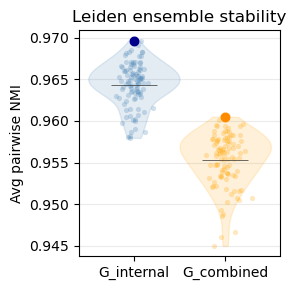

Internal:  μ=0.9644  σ=0.0026  medoid=0.9696
Combined:  μ=0.9553  σ=0.0032  medoid=0.9605


In [8]:
def plot_nmi_stability(stats_int, stats_comb):
    """Light side-by-side violin plots with jitter and medoid markers."""
    def avg_nmi(stats):
        m = stats['nmi_matrix']
        return (m.sum(axis=1) - 1) / (m.shape[0] - 1)

    nmi_int = avg_nmi(stats_int)
    nmi_comb = avg_nmi(stats_comb)

    fig, ax = plt.subplots(figsize=(3, 3))
    data = [nmi_int, nmi_comb]
    positions = [0, 1]

    vp = ax.violinplot(
        data,
        positions=positions,
        widths=1,
        showmeans=True,
        showmedians=False,
        showextrema=False,
    )
    for body, color in zip(vp['bodies'], ['steelblue', 'orange']):
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.15)
    vp['cmeans'].set_color('#333333')
    vp['cmeans'].set_linewidth(0.5)

    rng = np.random.default_rng(42)
    jitter_width = 0.1
    ax.scatter(
        rng.normal(positions[0], jitter_width, size=len(nmi_int)),
        nmi_int,
        s=14, color='steelblue', alpha=0.25, linewidths=0,
    )
    ax.scatter(
        rng.normal(positions[1], jitter_width, size=len(nmi_comb)),
        nmi_comb,
        s=14, color='orange', alpha=0.25, linewidths=0,
    )

    med_int = nmi_int[stats_int['medoid_idx']]
    med_comb = nmi_comb[stats_comb['medoid_idx']]
    ax.scatter(positions[0], med_int, s=55, color='darkblue', edgecolors='white', linewidths=0.2, zorder=2)
    ax.scatter(positions[1], med_comb, s=55, color='darkorange', edgecolors='white', linewidths=0.2, zorder=2)

    ax.set_xticks(positions)
    ax.set_xticklabels(['G_internal', 'G_combined'])
    ax.set_ylabel('Avg pairwise NMI')
    ax.set_title('Leiden ensemble stability')
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    print(f"Internal:  μ={nmi_int.mean():.4f}  σ={nmi_int.std():.4f}  medoid={med_int:.4f}")
    print(f"Combined:  μ={nmi_comb.mean():.4f}  σ={nmi_comb.std():.4f}  medoid={med_comb:.4f}")

plot_nmi_stability(leiden_internal_stats, leiden_combined_stats)

### Semantic profile - Fields of Study (FOS)

For the top `TOP_N_COMMS` communities, we extract the `TOP_K` most frequent FOS labels.
Cell color encodes label share within each community.

FOS values are split on `;` and filtered to 4-digit sub-discipline codes (`level='sub'`, e.g. `0302 clinical medicine`).
This avoids composite strings that would distort frequency and purity metrics.

In [9]:
_LEVEL_RE = {
    'macro': re.compile(r'^\d{2}\s'),
    'sub':   re.compile(r'^\d{4}\s'),
}

def parse_labels(val, level='sub'):
    """Split labels and optionally filter to macro/sub FOS levels."""
    if not val:
        return []
    parts = [p.strip() for p in str(val).split(';') if p.strip()]
    pattern = _LEVEL_RE.get(level)
    return [p for p in parts if pattern.match(p)] if pattern else parts

In [10]:
def extract_semantic_topk(partition, G, attr='FOS', level='sub',
                          top_n=TOP_N_COMMS, top_k=TOP_K):
    """Top-K labels per community for the largest top_n communities."""
    communities = sorted(partition.communities, key=len, reverse=True)[:top_n]
    rows = []
    for rank, comm in enumerate(communities, 1):
        counter = Counter()
        for node in comm:
            counter.update(parse_labels(G.nodes[node].get(attr), level=level))
        total = sum(counter.values())
        top_terms = counter.most_common(top_k)
        top_terms += [('N/A', 0)] * (top_k - len(top_terms))
        for pos, (term, cnt) in enumerate(top_terms, 1):
            rows.append({
                'CommunityRank': rank,
                'CommunitySize': len(comm),
                'Position': pos,
                'Term': term,
                'Count': cnt,
                'Share': cnt / total if total else 0,
            })
    return pd.DataFrame(rows)

In [11]:
def plot_semantic_topk(df_int, df_comb, semantic_name='FOS', cmap='YlGnBu'):
    """Side-by-side heatmap of top-K labels per community for internal vs combined."""
    top_k = int(df_int['Position'].max())

    def _build_matrix(df):
        comms = sorted(df['CommunityRank'].unique())
        val_mat = np.zeros((len(comms), top_k))
        lbl_mat = [['' for _ in range(top_k)] for _ in range(len(comms))]
        ylabels = []
        for i, c in enumerate(comms):
            rows = df[df['CommunityRank'] == c].sort_values('Position')
            ylabels.append(f"C{c} (n={int(rows['CommunitySize'].iloc[0])})")
            for _, r in rows.iterrows():
                j = int(r['Position']) - 1
                val_mat[i, j] = r['Share']
                term = textwrap.shorten(str(r['Term']), width=24, placeholder='...')
                lbl_mat[i][j] = f"{term}\n{int(r['Count'])} ({r['Share']*100:.1f}%)"
        return val_mat, lbl_mat, ylabels

    mat_i, lbl_i, y_i = _build_matrix(df_int)
    mat_c, lbl_c, y_c = _build_matrix(df_comb)
    vmax = max(mat_i.max(), mat_c.max(), 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
    for ax, mat, lbls, ylabs, title in [
        (axes[0], mat_i, lbl_i, y_i, f'{semantic_name} — G_internal'),
        (axes[1], mat_c, lbl_c, y_c, f'{semantic_name} — G_combined'),
    ]:
        im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=0, vmax=vmax)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xticks(range(top_k))
        ax.set_xticklabels([f'Top {i+1}' for i in range(top_k)])
        ax.set_yticks(range(len(ylabs)))
        ax.set_yticklabels(ylabs, fontsize=9)
        ax.set_xlabel('Label rank within community')
        ax.set_ylabel('Community')
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(j, i, lbls[i][j], ha='center', va='center',
                        fontsize=7.5, color='black')

    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9,
                 label='Label share within community')
    plt.show()

In [12]:
# FOS sub-discipline (4-digit)
df_fos_int  = extract_semantic_topk(leiden_internal, G_internal_undir, attr='FOS', level='sub')
df_fos_comb = extract_semantic_topk(leiden_combined, G_combined,       attr='FOS', level='sub')

# FOS macro-discipline (2-digit)
df_fos_l2_int  = extract_semantic_topk(leiden_internal, G_internal_undir, attr='FOS', level='macro')
df_fos_l2_comb = extract_semantic_topk(leiden_combined, G_combined,       attr='FOS', level='macro')

# SDG
df_sdg_int  = extract_semantic_topk(leiden_internal, G_internal_undir, attr='SDG', level='all')
df_sdg_comb = extract_semantic_topk(leiden_combined, G_combined,       attr='SDG', level='all')

# plot_semantic_topk(df_fos_int, df_fos_comb, semantic_name='FOS', cmap='PuBuGn')
# plot_semantic_topk(df_fos_l2_int, df_fos_l2_comb, semantic_name='FOS L2', cmap='PuBuGn')
# plot_semantic_topk(df_sdg_int, df_sdg_comb, semantic_name='SDG', cmap='YlOrBr')

### Internal vs combined partition comparison

We align Leiden partitions on common nodes and compare them with NMI, ARI, VI, and best-match Jaccard.
Goal: measure which communities stay stable and which are reorganized after adding BC edges.

In [13]:
def _entropy(labels):
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log(p + 1e-12))

def variation_of_information(labels_a, labels_b):
    """VI = H(A) + H(B) - 2 * I(A,B)."""
    return (_entropy(labels_a) + _entropy(labels_b)
            - 2.0 * mutual_info_score(labels_a, labels_b))

def _partition_to_sets(partition, allowed_nodes=None, min_size=1):
    result = []
    for comm in partition.communities:
        s = set(comm)
        if allowed_nodes is not None:
            s &= allowed_nodes
        if len(s) >= min_size:
            result.append(s)
    return result

### Size distribution

A compact two-panel view highlights structural differences between `G_internal` and `G_combined`:
- rank-size curve on log-log axes
- cumulative node coverage across ranked communities

In [14]:
def plot_size_distribution(partition_a, label_a, partition_b, label_b,
                           color_a='#2563EB', color_b='#F59E0B',
                           title='', thresholds=(0.50, 0.80, 0.95),
                           include_curves=False):
    """Rank-size plot + improved tabular summary with 10/50/80/95 coverage."""

    def _sizes(partition):
        sizes = sorted((len(c) for c in partition.communities), reverse=True)
        if not sizes:
            raise ValueError('Partition has no communities.')
        return np.asarray(sizes, dtype=float)

    def _summary(arr):
        cov = np.cumsum(arr) / arr.sum()
        summary = {
            'n': len(arr),
            'min': int(arr.min()),
            'max': int(arr.max()),
            'mean': float(arr.mean()),
            'median': float(np.median(arr)),
            'coverage': {k: float(arr[:min(k, len(arr))].sum() / arr.sum())
                         for k in (10, 50, 80, 95)},
            'nodes_for_thr': {
                thr: int(np.searchsorted(cov, thr, side='left') + 1)
                for thr in thresholds
            },
        }
        if include_curves:
            summary['cov'] = cov
        return summary, cov

    sizes_a = _sizes(partition_a)
    sizes_b = _sizes(partition_b)
    stats_a, cov_a = _summary(sizes_a)
    stats_b, cov_b = _summary(sizes_b)

    # Plot: rank-size (log-log)
    fig, ax = plt.subplots(figsize=(4, 3))
    rank_a = np.arange(1, len(sizes_a) + 1)
    rank_b = np.arange(1, len(sizes_b) + 1)
    
    ax.plot(rank_a, sizes_a, color=color_a, lw=1.5, alpha=0.9, label=label_a)
    ax.plot(rank_b, sizes_b, color=color_b, lw=1.5, alpha=0.9, label=label_b)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Community rank (log)', fontsize=11)
    ax.set_ylabel('Size in nodes (log)', fontsize=11)
    ax.grid(True, which='both', alpha=0.2)
    ax.set_facecolor('#FAFAFA')
    ax.legend(fontsize=9, loc='upper right', framealpha=0.95)
    
    plt.tight_layout()
    plt.show()

    # Table: size distribution summary
    table_data = []
    for label, stats in ((label_a, stats_a), (label_b, stats_b)):
        row = {
            'Graph': label,
            'n_comms': stats['n'],
            'min': stats['min'],
            'max': stats['max'],
            'mean': f"{stats['mean']:.1f}",
            'median': f"{stats['median']:.1f}",
            'cov_10': f"{stats['coverage'][10]:.1%}",
            'cov_50': f"{stats['coverage'][50]:.1%}",
            'cov_80': f"{stats['coverage'][80]:.1%}",
            'cov_95': f"{stats['coverage'][95]:.1%}",
            'k_50%': stats['nodes_for_thr'][0.50],
            'k_80%': stats['nodes_for_thr'][0.80],
            'k_95%': stats['nodes_for_thr'][0.95],
        }
        table_data.append(row)

    df_summary = pd.DataFrame(table_data)
    
    print("\nSIZE DISTRIBUTION SUMMARY")
    print("=" * 130)
    print(df_summary.to_string(index=False))
    print("=" * 130)
    print("\nLegend:")
    print("  n_comms: number of communities")
    print("  min/max/mean/median: community size statistics")
    print("  cov_K: fraction of nodes covered by top-K communities")
    print("  k_XX%: number of communities needed to reach XX% coverage")

    return {
        label_a: stats_a,
        label_b: stats_b,
    }


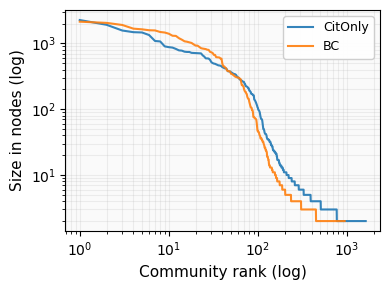


SIZE DISTRIBUTION SUMMARY
  Graph  n_comms  min  max mean median cov_10 cov_50 cov_80 cov_95  k_50%  k_80%  k_95%
CitOnly     1624    2 2258 33.9    2.0  25.3%  66.2%  81.2%  85.5%     30     77    443
     BC      942    2 2133 62.2    2.0  28.8%  78.8%  91.3%  93.7%     22     53    114

Legend:
  n_comms: number of communities
  min/max/mean/median: community size statistics
  cov_K: fraction of nodes covered by top-K communities
  k_XX%: number of communities needed to reach XX% coverage


{'CitOnly': {'n': 1624,
  'min': 2,
  'max': 2258,
  'mean': 33.91502463054187,
  'median': 2.0,
  'coverage': {10: 0.25316823414067324,
   50: 0.6617887359744362,
   80: 0.811648934238716,
   95: 0.8552235012164566},
  'nodes_for_thr': {0.5: 30, 0.8: 77, 0.95: 443}},
 'BC': {'n': 942,
  'min': 2,
  'max': 2133,
  'mean': 62.23673036093418,
  'median': 2.0,
  'coverage': {10: 0.28797311818786564,
   50: 0.7882545584798812,
   80: 0.9133846180087672,
   95: 0.9365138929162331},
  'nodes_for_thr': {0.5: 22, 0.8: 53, 0.95: 114}}}

In [15]:
plot_size_distribution(
    leiden_internal, 'CitOnly',
    leiden_combined, 'BC',
    color_a='tab:blue', color_b='tab:orange',
    title='',
)

In [16]:
def compute_semantic_purity(clustering, G, attr='FOS', level='macro', min_size=10):
    """Weighted entropy and Gini per community (filtered by min_size)."""
    def _gini(counts):
        if len(counts) == 0:
            return 0.0
        s = np.sort(counts.astype(float))
        n = len(s)
        return (2 * np.sum(np.arange(1, n+1) * s)) / (n * s.sum()) - (n+1) / n

    entropies, ginis, sizes = [], [], []
    for comm in clustering.communities:
        if len(comm) < min_size:
            continue
        labels = []
        for node in comm:
            labels.extend(parse_labels(G.nodes[node].get(attr), level=level))
        if not labels:
            continue
        _, counts = np.unique(labels, return_counts=True)
        # Normalized entropy
        probs = counts / counts.sum()
        H = scipy_entropy(probs, base=2)
        H_max = np.log2(len(counts)) if len(counts) > 1 else 1.0
        entropies.append(H / H_max if H_max > 0 else 0.0)
        ginis.append(_gini(counts))
        sizes.append(len(comm))

    sizes = np.array(sizes)
    total = sizes.sum()
    return {
        'entropy': (np.array(entropies) * sizes).sum() / total,
        'gini':    (np.array(ginis) * sizes).sum() / total,
        'n_comms': len(sizes),
    }


def print_purity_comparison(leiden_int, leiden_comb, G_int, G_comb, min_size=10):
    """Compare and print semantic purity: internal vs combined."""
    print("\n" + "=" * 80)
    print("SEMANTIC PURITY ANALYSIS")
    print("=" * 80)

    for key, attr, level in [('FOS_L2', 'FOS', 'macro'), ('FOS', 'FOS', 'sub'), ('SDG', 'SDG', 'all')]:
        p_int  = compute_semantic_purity(leiden_int,  G_int,  attr=attr, level=level, min_size=min_size)
        p_comb = compute_semantic_purity(leiden_comb, G_comb, attr=attr, level=level, min_size=min_size)

        de = p_comb['entropy'] - p_int['entropy']
        dg = p_comb['gini'] - p_int['gini']
        e_verdict = "WORSE" if de > 0.01 else ("BETTER" if de < -0.01 else "SAME")
        g_verdict = "BETTER" if dg > 0.01 else ("WORSE" if dg < -0.01 else "SAME")

        print(f"\n{key}:")
        print(f"  Internal  | Entropy: {p_int['entropy']:.4f} | Gini: {p_int['gini']:.4f} | Comms: {p_int['n_comms']}")
        print(f"  Combined  | Entropy: {p_comb['entropy']:.4f} | Gini: {p_comb['gini']:.4f} | Comms: {p_comb['n_comms']}")
        print(f"  Δ Combined vs Internal: Entropy {de:+.4f} ({e_verdict}) | Gini {dg:+.4f} ({g_verdict})")

    print("=" * 80)

print_purity_comparison(leiden_internal, leiden_combined, G_internal_undir, G_combined)


SEMANTIC PURITY ANALYSIS

FOS_L2:
  Internal  | Entropy: 0.3927 | Gini: 0.5742 | Comms: 221
  Combined  | Entropy: 0.3975 | Gini: 0.6179 | Comms: 158
  Δ Combined vs Internal: Entropy +0.0048 (SAME) | Gini +0.0437 (BETTER)

FOS:
  Internal  | Entropy: 0.5028 | Gini: 0.7162 | Comms: 221
  Combined  | Entropy: 0.4813 | Gini: 0.7598 | Comms: 158
  Δ Combined vs Internal: Entropy -0.0215 (BETTER) | Gini +0.0436 (BETTER)

SDG:
  Internal  | Entropy: 0.5658 | Gini: 0.6829 | Comms: 213
  Combined  | Entropy: 0.5612 | Gini: 0.6980 | Comms: 155
  Δ Combined vs Internal: Entropy -0.0046 (SAME) | Gini +0.0152 (BETTER)


### Fate analysis - impact of BC edges

Each community in `leiden_internal` is classified by its outcome in `leiden_combined`.

| Fate | Rule | Meaning |
|---|---|---|
| stable | best Jaccard >= 0.50 | mostly preserved |
| merged | >=2 internal communities map to one combined | unified by BC |
| split | one internal maps to >=2 combined | fragmented by BC |
| dissolved | best Jaccard < 0.20 | no clear counterpart |
| partial | otherwise | mixed reshaping |

Only communities with size >= 50 are analyzed to avoid micro-community noise.

Cross-domain merge: merged components have different dominant FOS labels (L2).

In [17]:
def get_top_labels(comm, G, attr='FOS', level='sub', top_k=3):
    """Return top labels as 'Label (n%)' string."""
    counter = Counter()
    for node in comm:
        counter.update(parse_labels(G.nodes[node].get(attr), level=level))
    total = sum(counter.values())
    if not total:
        return 'N/A'
    return ' | '.join(f"{k} ({v/total:.0%})" for k, v in counter.most_common(top_k))


def classify_community_fates(part_a, part_b, G,
                              name_a='A', name_b='B',
                              stable_thr=0.5, dissolved_thr=0.20,
                              min_size=50, attr='FOS', level='sub'):
    """Classify each community in part_a by its fate in part_b."""
    common = ({n for c in part_a.communities for n in c}
              & {n for c in part_b.communities for n in c})
    a_sets = _partition_to_sets(part_a, common, min_size)
    b_sets = _partition_to_sets(part_b, common, min_size)

    b_to_a_groups = defaultdict(list)
    rows = []

    for a_id, A in enumerate(a_sets):
        overlap = {b_id: len(A & B) / len(A | B)
                   for b_id, B in enumerate(b_sets) if A & B}

        if not overlap:
            rows.append({'a_id': a_id, 'size_a': len(A),
                         'best_jacc': 0.0, 'best_b_id': None,
                         'n_b_touched': 0, 'top_b_frac': 0.0,
                         'top_fos': get_top_labels(A, G, attr=attr, level=level),
                         'fate': 'dissolved'})
            continue

        best_b = max(overlap, key=overlap.get)
        top_b_frac = len(A & b_sets[best_b]) / len(A)
        n_touched = sum(1 for v in overlap.values() if v > 0.05)
        b_to_a_groups[best_b].append(a_id)
        rows.append({'a_id': a_id, 'size_a': len(A),
                     'best_jacc': round(overlap[best_b], 4), 'best_b_id': best_b,
                     'n_b_touched': n_touched,
                     'top_b_frac': round(top_b_frac, 3),
                     'top_fos': get_top_labels(A, G, attr=attr, level=level),
                     'fate': '__pending__'})

    df = pd.DataFrame(rows)

    b_group_size = df['best_b_id'].map(
        lambda bid: len(b_to_a_groups[bid]) if bid is not None else 0
    )
    df['fate'] = np.select(
        [df['fate'] == 'dissolved',
         df['best_jacc'] >= stable_thr,
         b_group_size > 1,
         (df['n_b_touched'] >= 2) & (df['top_b_frac'] < 0.70),
         df['best_jacc'] < dissolved_thr],
        ['dissolved', 'stable', 'merged', 'split', 'dissolved'],
        default='partial',
    )

    merge_events = []
    for b_id, a_ids in b_to_a_groups.items():
        if len(a_ids) < 2:
            continue
        event_comms = [a_sets[i] for i in a_ids]
        fos_profiles = [get_top_labels(c, G, attr=attr, top_k=2, level=level)
                        for c in event_comms]
        b_fos = get_top_labels(b_sets[b_id], G, attr=attr, top_k=3, level=level)
        unique_dom = len({p.split(' | ')[0].split(' (')[0] for p in fos_profiles})
        merge_events.append({
            'b_id': b_id, 'b_size': len(b_sets[b_id]),
            'n_merged': len(a_ids), 'a_sizes': [len(c) for c in event_comms],
            'fos_profiles': fos_profiles, 'b_fos': b_fos,
            'cross_domain': unique_dom > 1,
        })
    merge_events.sort(key=lambda x: x['b_size'], reverse=True)

    map_a = {n: cid for cid, s in enumerate(a_sets) for n in s}
    map_b = {n: cid for cid, s in enumerate(b_sets) for n in s}
    common_nodes = sorted(set(map_a) & set(map_b))
    la = np.array([map_a[n] for n in common_nodes])
    lb = np.array([map_b[n] for n in common_nodes])
    nmi = normalized_mutual_info_score(la, lb, average_method='arithmetic')
    vi = variation_of_information(la, lb)

    print(f'\n{"="*60}')
    print(f'  Fate Analysis: {name_a} -> {name_b}')
    print(f'{"="*60}')
    print(f'  Communities analysed (>={min_size} nodes): {len(df)}')
    print(f'  NMI: {nmi:.4f}  |  VI: {vi:.4f}')
    for fate, grp in df.groupby('fate'):
        pct = len(grp) / len(df) * 100
        print(f'    {fate:<12s} {len(grp):>4d}  ({pct:5.1f}%)  {"#" * int(pct/2)}')
    n_cross = sum(e['cross_domain'] for e in merge_events)
    print(f'\n  Merge events: {len(merge_events)}  |  Cross-domain: {n_cross}')

    return df, merge_events, {'NMI': nmi, 'VI': vi}


def print_merge_report(merge_events, top_n=10):
    """Print top-N merge events with FOS profiles."""
    print(f'\n{"="*65}')
    print(f'  TOP {top_n} MERGE EVENTS  (components >= 50 nodes)')
    print(f'{"="*65}')
    for i, ev in enumerate(merge_events[:top_n]):
        tag = '[cross-domain]' if ev['cross_domain'] else '[same-domain]'
        print(f'\n  [{i+1}] {tag}  -  {ev["n_merged"]} comms -> 1  (merged size: {ev["b_size"]})')
        print(f'       Merged FOS: {ev["b_fos"]}')
        for j, (fos, sz) in enumerate(zip(ev['fos_profiles'], ev['a_sizes'])):
            print(f'         C{j+1} (n={sz:>5d}): {fos}')

In [18]:
df_fates_leiden, merge_events_leiden, global_leiden = classify_community_fates(
    part_a   = leiden_internal,
    part_b   = leiden_combined,
    G        = G_combined,
    name_a   = 'Leiden/Internal',
    name_b   = 'Leiden/Combined',
    attr     = 'FOS',
    level    = 'sub',
    min_size = MIN_COMM_SIZE,
)


  Fate Analysis: Leiden/Internal -> Leiden/Combined
  Communities analysed (>=50 nodes): 116
  NMI: 0.8568  |  VI: 1.2334
    merged         41  ( 35.3%)  #################
    partial         3  (  2.6%)  #
    split           2  (  1.7%)  
    stable         70  ( 60.3%)  ##############################

  Merge events: 22  |  Cross-domain: 11


In [19]:
print_merge_report(merge_events_leiden, top_n=10)


  TOP 10 MERGE EVENTS  (components >= 50 nodes)

  [1] [same-domain]  -  4 comms -> 1  (merged size: 2036)
       Merged FOS: 0302 clinical medicine (43%) | 0301 basic medicine (35%) | 0303 health sciences (21%)
         C1 (n= 1462): 0302 clinical medicine (44%) | 0301 basic medicine (35%)
         C2 (n=  261): 0302 clinical medicine (70%) | 0301 basic medicine (19%)
         C3 (n=  169): 0302 clinical medicine (40%) | 0301 basic medicine (36%)
         C4 (n=  117): 0302 clinical medicine (74%) | 0301 basic medicine (12%)

  [2] [same-domain]  -  2 comms -> 1  (merged size: 1994)
       Merged FOS: 0301 basic medicine (30%) | 0303 health sciences (21%) | 0106 biological sciences (17%)
         C1 (n= 1913): 0301 basic medicine (29%) | 0303 health sciences (20%)
         C2 (n=  107): 0301 basic medicine (51%) | 0303 health sciences (45%)

  [3] [cross-domain]  -  2 comms -> 1  (merged size: 1537)
       Merged FOS: 0105 earth and related environmental sciences (56%) | 0601 history

### Merge analysis - observations

With the >=50 filter, we detect 21 merge events (9 cross-domain).
Top-size merges are mostly intra-domain, especially within medical sub-fields.

Main cross-domain signals:
- Earth sciences + archaeology/medicine (likely archaeometry)
- Chemistry/nanotechnology + basic medicine (possible pharma links)

Takeaway: BC mostly resolves fragmentation within broad domains; cross-domain bridges exist but are less frequent among largest merges.

### Summary - Leiden

- BC increases edges strongly (218k -> 649k) while modularity stays high (0.957 -> 0.932).
- Ensemble stability remains high (mean NMI about 0.96, std < 0.005).
- Communities shrink from 1,620 to 964 (-40.5%), mainly by merges, not splits.
- Fate analysis (size >=50): most communities are stable; merges are the main transformation.
- Largest merges are mostly intra-disciplinary (especially medical areas).
- Semantic purity is preserved (weighted Gini improves on combined graph).
- SDG structure remains polarized around health and sustainability/technology themes.